# 02 — Analyse de la parité femmes/hommes dans l'industrie française (2017–2024)

**Source :** INSEE, Enquête Emploi en continu — CSS02  
**Données :** `data/processed/parite_analyse_2017_2024.csv` (généré par `01_data_cleaning.ipynb`)

---

### Graphiques produits
1. **Courbes de tendance** — évolution % femmes par secteur (2017–2024)
2. **Heatmap** — vue matricielle secteur × année
3. **Bar chart comparatif** — classement des secteurs par féminisation (dernière année)
4. **Graphique interactif Plotly** — tendances dynamiques (export HTML)

In [4]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.4 MB/s  0:00:02a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]


## 0. Imports et chargement des données

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chargement
df = pd.read_csv(PROC_DIR / 'parite_analyse_2017_2024.csv', sep=';', encoding='utf-8-sig')
df_pivot = pd.read_csv(PROC_DIR / 'parite_pivot_part_femmes.csv', sep=';',
                       encoding='utf-8-sig', index_col=0)
df_pivot.columns = df_pivot.columns.astype(int)

# Paramètres globaux matplotlib
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

ANNEES = sorted(df['annee'].unique())
SECTEURS = sorted(df['secteur'].unique())
ANNEE_RUPTURE = 2021  # Refonte enquête INSEE

print(f'✓ {len(df)} lignes chargées')
print(f'  Années  : {ANNEES}')
print(f'  Secteurs: {len(SECTEURS)}')
df.head()

✓ 96 lignes chargées
  Années  : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Secteurs: 12


,annee,secteur,pop_femmes,pop_total,part_femmes
0,2017,Activités financières et assurance,511.6,864.4,59.2
1,2017,Activités informatiques,108.9,430.7,25.3
2,2017,Activités spécialisées et soutien,1232.8,2649.5,46.5
3,2017,"Admin. publique, enseignement, santé",5742.1,8327.7,69.0
4,2017,"Agriculture, sylviculture et pêche",205.7,697.9,29.5


## 1. Courbes de tendance par secteur

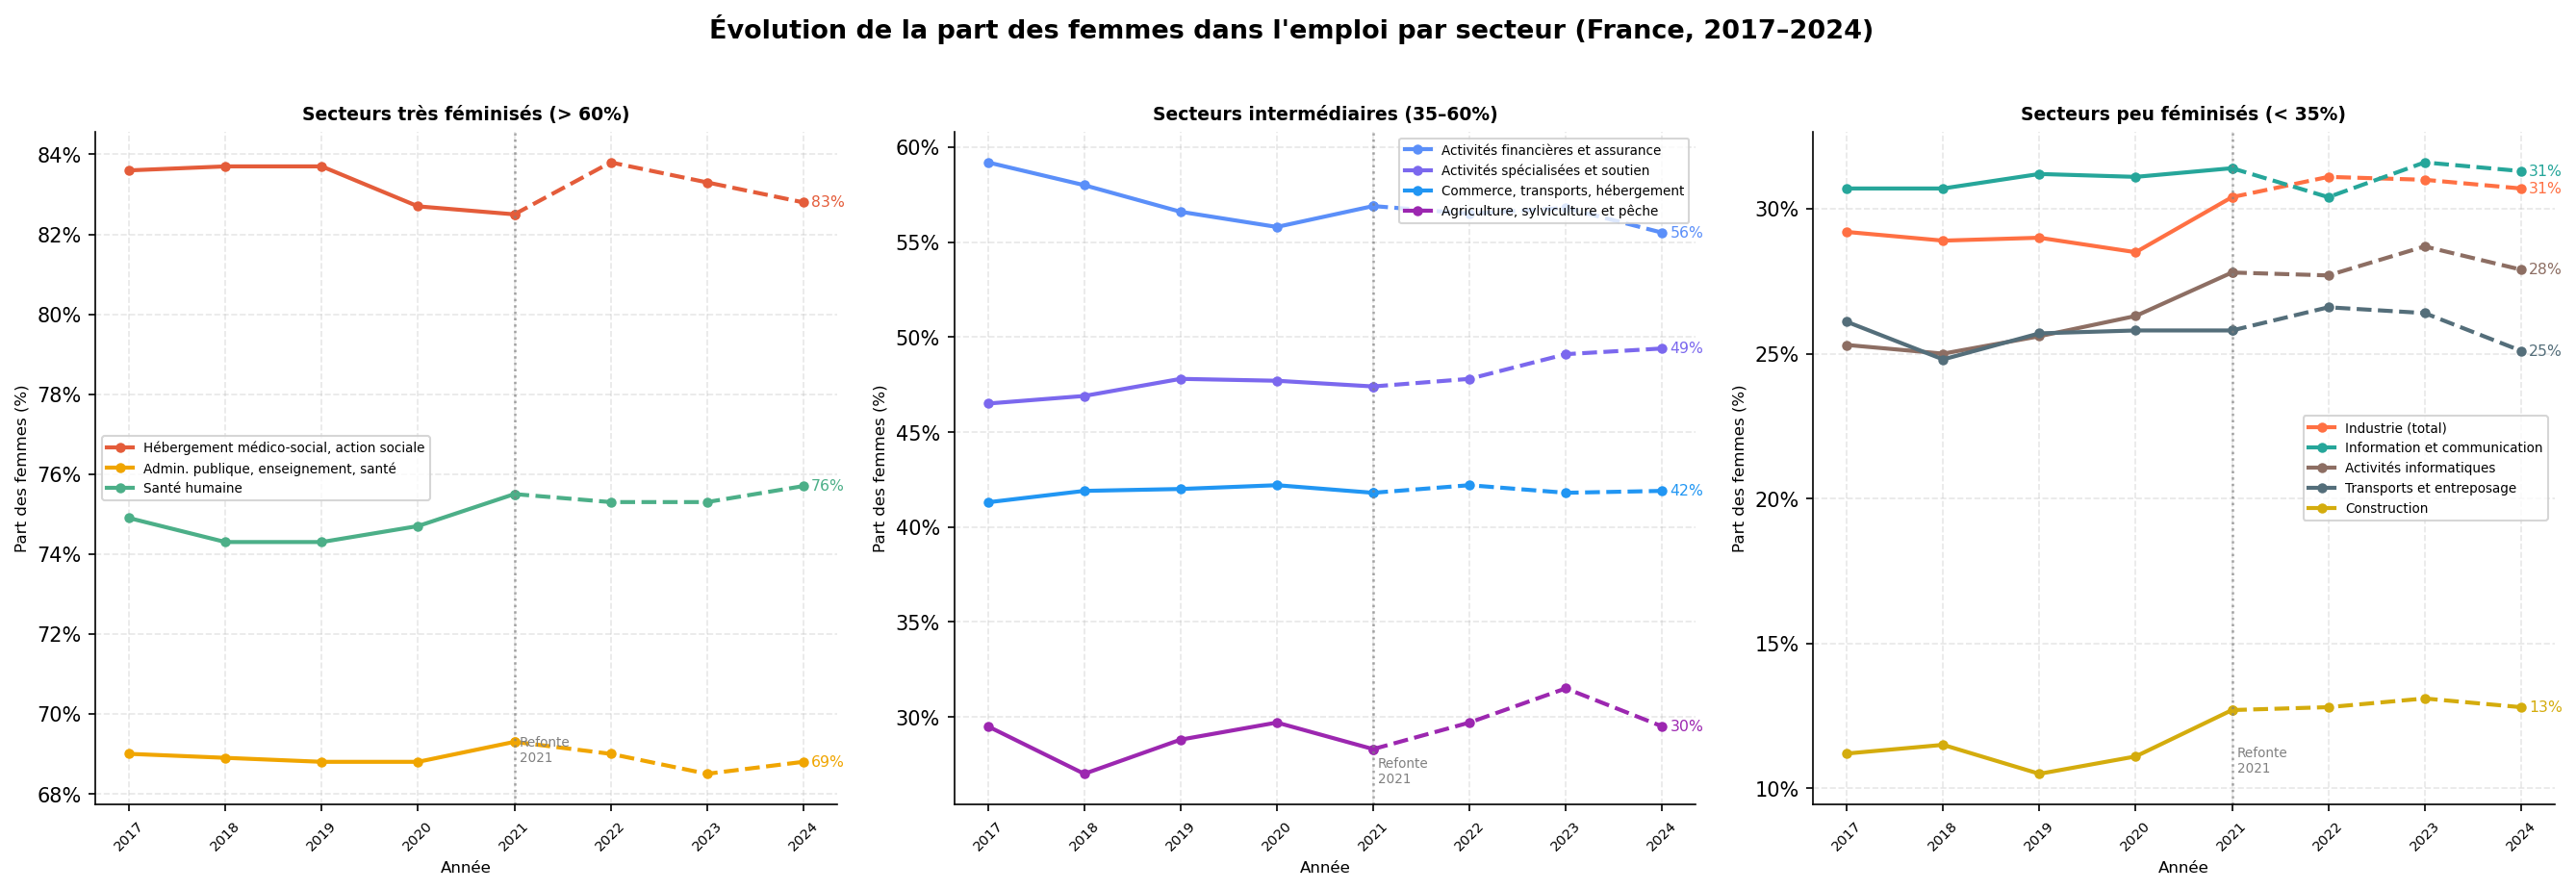

✓ Sauvegardé : outputs/figures/01_tendances_secteurs.png


In [6]:
# Grouper les secteurs en 3 familles pour la lisibilité
GROUPES = {
    'Secteurs très féminisés (> 60%)': [
        'Hébergement médico-social, action sociale',
        'Admin. publique, enseignement, santé',
        'Santé humaine',
    ],
    'Secteurs intermédiaires (35–60%)': [
        'Activités financières et assurance',
        'Activités spécialisées et soutien',
        'Commerce, transports, hébergement',
        'Agriculture, sylviculture et pêche',
    ],
    'Secteurs peu féminisés (< 35%)': [
        'Industrie (total)',
        'Information et communication',
        'Activités informatiques',
        'Transports et entreposage',
        'Construction',
    ],
}

COULEURS = [
    '#E45C3A','#F0A500','#4CAF88',  # féminisés
    '#5B8FF9','#7B68EE','#2196F3','#9C27B0',  # intermédiaires
    '#FF7043','#26A69A','#8D6E63','#546E7A','#D4AC0D',  # peu féminisés
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle('Évolution de la part des femmes dans l\'emploi par secteur (France, 2017–2024)',
             fontsize=13, fontweight='bold', y=1.02)

color_idx = 0
for ax, (titre, secteurs) in zip(axes, GROUPES.items()):
    for secteur in secteurs:
        data_s = df[df['secteur'] == secteur].sort_values('annee')
        if data_s.empty:
            continue
        couleur = COULEURS[color_idx % len(COULEURS)]
        color_idx += 1

        # Tracer en deux segments (avant/après rupture) pour matérialiser 2021
        pre  = data_s[data_s['annee'] <= ANNEE_RUPTURE]
        post = data_s[data_s['annee'] >= ANNEE_RUPTURE]

        ax.plot(pre['annee'],  pre['part_femmes'],
                marker='o', linewidth=2, markersize=4, color=couleur, label=secteur)
        ax.plot(post['annee'], post['part_femmes'],
                marker='o', linewidth=2, markersize=4, color=couleur, linestyle='--')

        # Valeur finale
        last = data_s.iloc[-1]
        ax.annotate(f"{last['part_femmes']:.0f}%",
                    xy=(last['annee'], last['part_femmes']),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=7.5, color=couleur, va='center')

    # Ligne de rupture 2021
    ax.axvline(x=ANNEE_RUPTURE, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(ANNEE_RUPTURE + 0.05, ax.get_ylim()[0] + 1, 'Refonte\n2021',
            fontsize=6.5, color='gray', va='bottom')

    ax.set_title(titre, fontsize=9, fontweight='bold')
    ax.set_xlabel('Année', fontsize=8)
    ax.set_ylabel('Part des femmes (%)', fontsize=8)
    ax.set_xticks(ANNEES)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=6.5, loc='best', framealpha=0.8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig(FIG_DIR / '01_tendances_secteurs.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Sauvegardé : outputs/figures/01_tendances_secteurs.png')

## 2. Heatmap — vue matricielle secteur × année

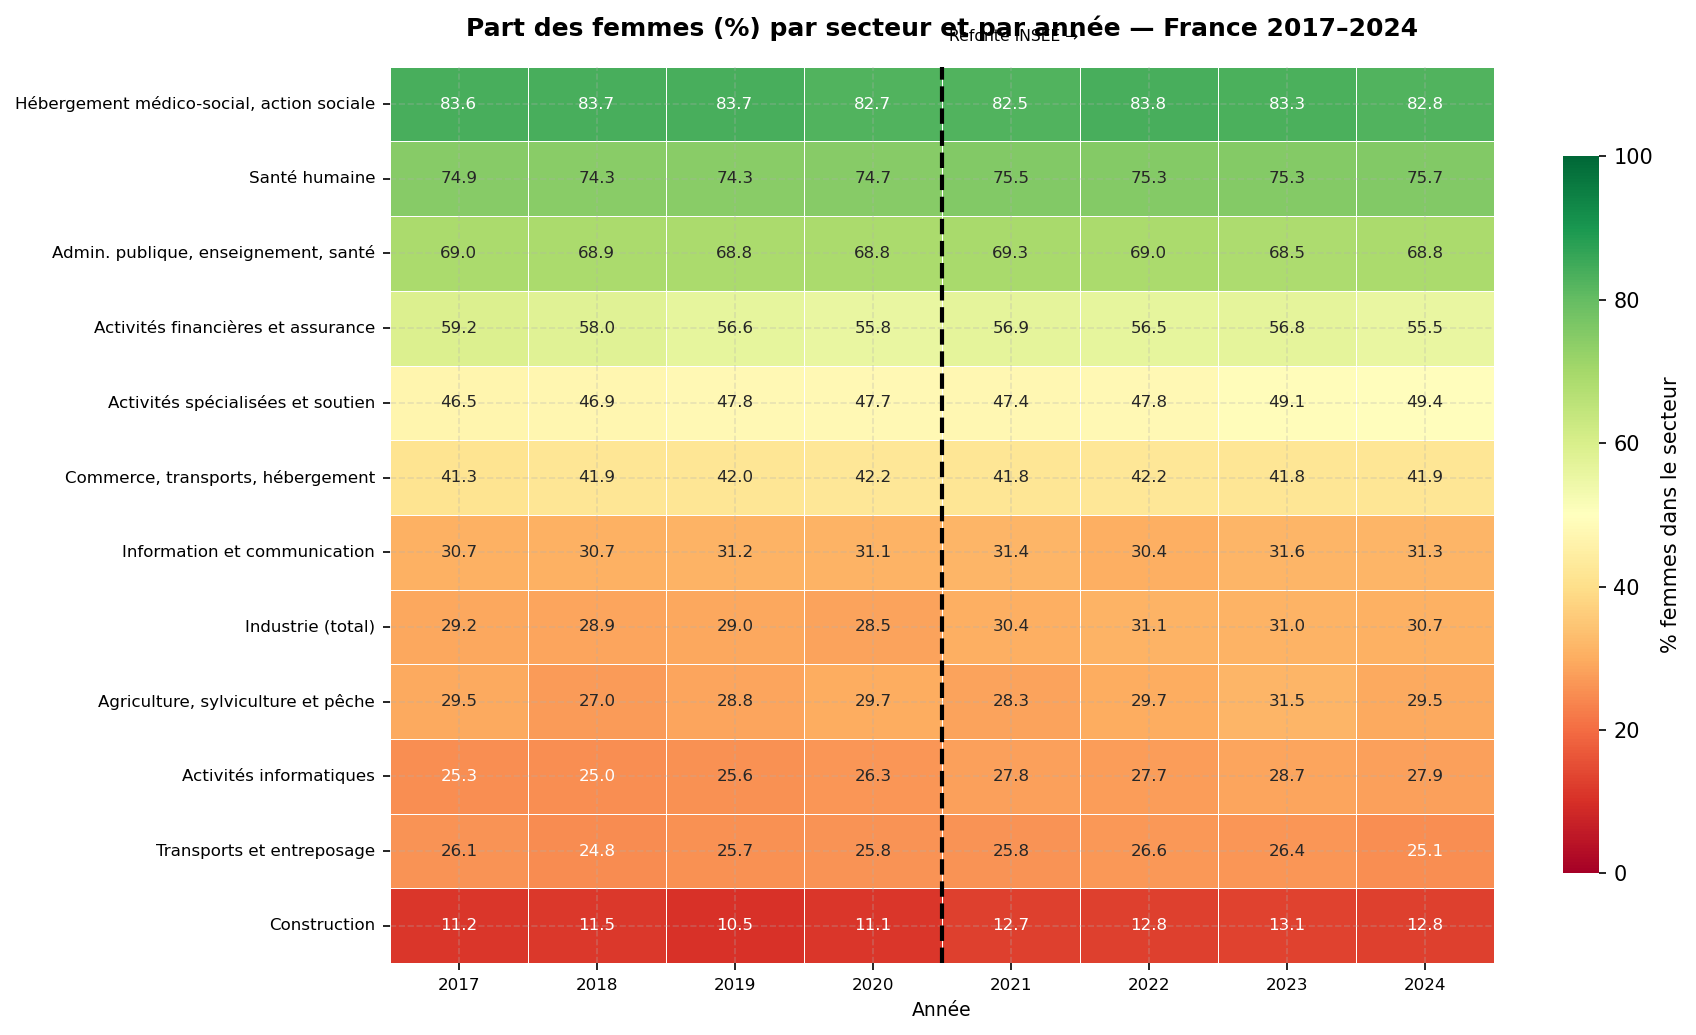

✓ Sauvegardé : outputs/figures/02_heatmap_secteurs.png


In [7]:
# Trier les secteurs par part_femmes 2024 (décroissant)
ordre = df_pivot[2024].sort_values(ascending=False).index.tolist()
pivot_ordonne = df_pivot.loc[ordre]

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    pivot_ordonne,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': '% femmes dans le secteur', 'shrink': 0.8},
    annot_kws={'size': 8},
)

# Ligne de rupture 2021 (entre colonnes 2020 et 2021)
col_rupture = list(df_pivot.columns).index(2021)
ax.axvline(x=col_rupture, color='black', linewidth=2, linestyle='--')
ax.text(col_rupture + 0.05, -0.5, 'Refonte INSEE →', fontsize=7.5,
        color='black', va='top', ha='left')

ax.set_title('Part des femmes (%) par secteur et par année — France 2017–2024',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Année', fontsize=9)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_heatmap_secteurs.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Sauvegardé : outputs/figures/02_heatmap_secteurs.png')

## 3. Bar chart — classement des secteurs (2017 vs 2024)

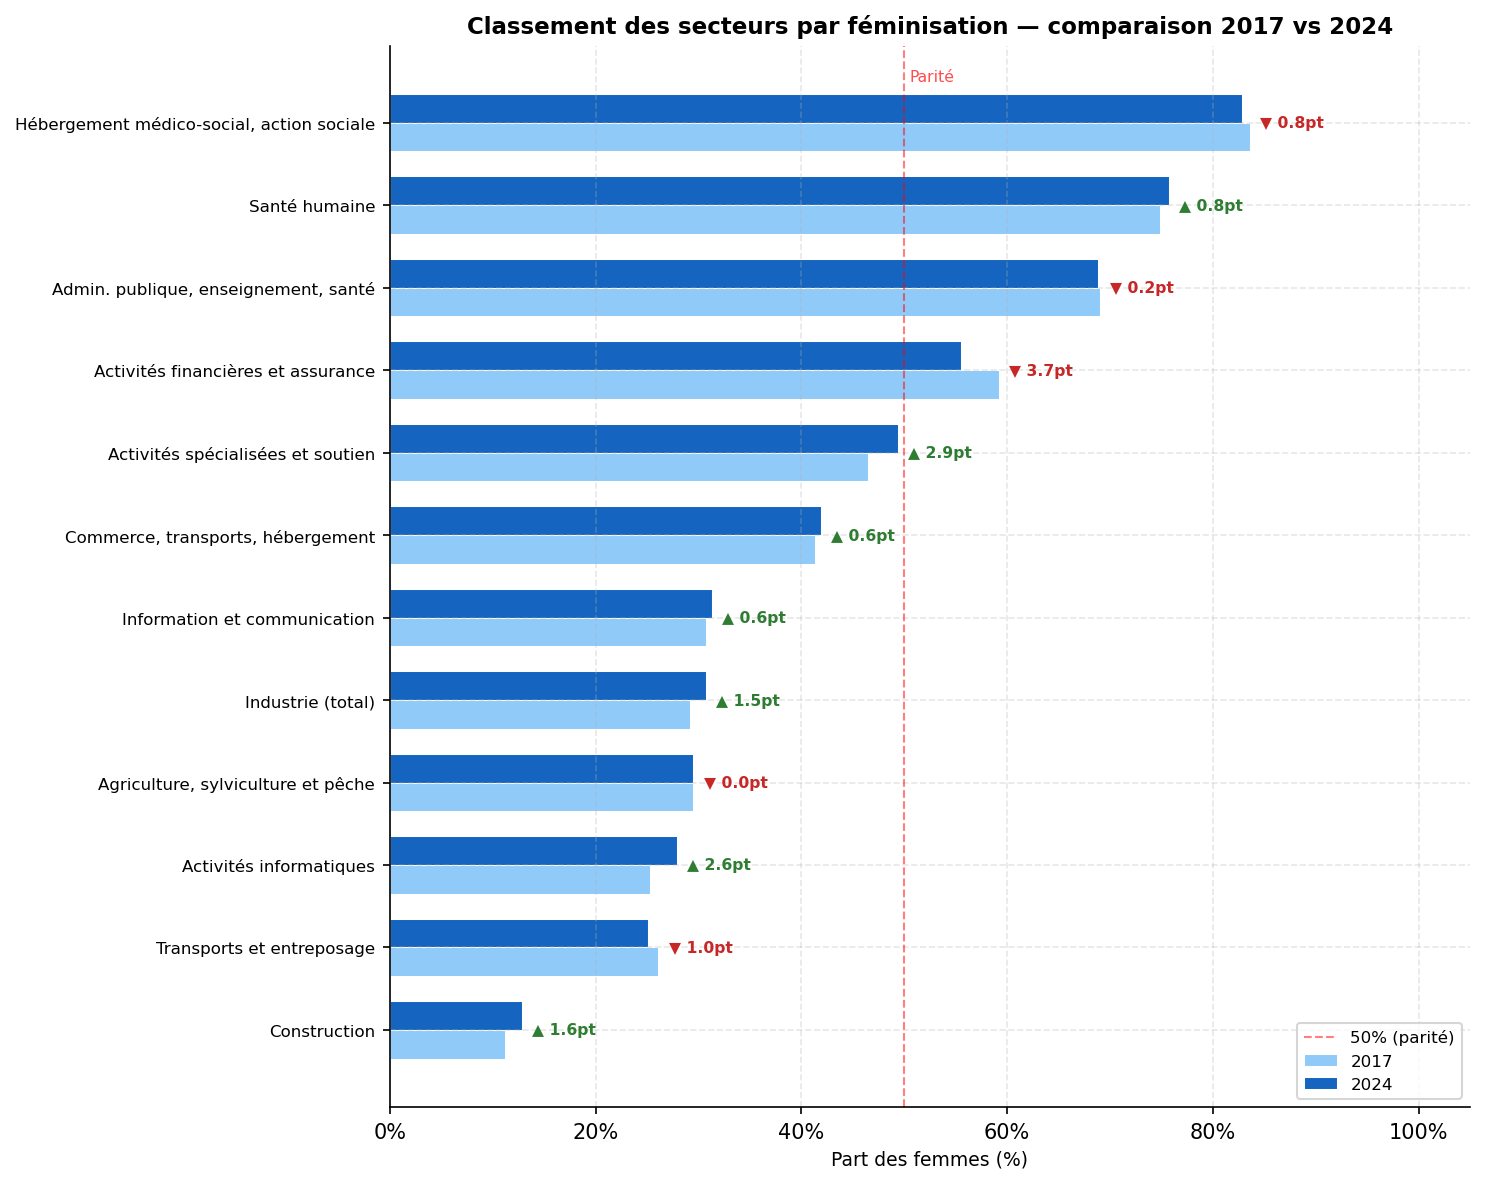

✓ Sauvegardé : outputs/figures/03_barchart_classement.png


In [8]:
# Comparer 2017 et 2024, triés par valeur 2024
df_bar = df_pivot[[2017, 2024]].dropna().sort_values(2024, ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(df_bar))
h = 0.35

bars_2017 = ax.barh(y - h/2, df_bar[2017], h, label='2017',
                    color='#90CAF9', edgecolor='white', linewidth=0.5)
bars_2024 = ax.barh(y + h/2, df_bar[2024], h, label='2024',
                    color='#1565C0', edgecolor='white', linewidth=0.5)

# Annoter les valeurs et les flèches de variation
for i, (secteur, row) in enumerate(df_bar.iterrows()):
    delta = row[2024] - row[2017]
    couleur = '#2E7D32' if delta > 0 else '#C62828'
    symbole = '▲' if delta > 0 else '▼'
    ax.text(max(row[2017], row[2024]) + 1, i,
            f'{symbole} {abs(delta):.1f}pt',
            va='center', fontsize=7.5, color=couleur, fontweight='bold')

# Ligne des 50%
ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% (parité)')
ax.text(50.5, len(df_bar) - 0.5, 'Parité', fontsize=7.5, color='red', alpha=0.7)

ax.set_yticks(y)
ax.set_yticklabels(df_bar.index, fontsize=8)
ax.set_xlabel('Part des femmes (%)', fontsize=9)
ax.set_title('Classement des secteurs par féminisation — comparaison 2017 vs 2024',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_barchart_classement.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Sauvegardé : outputs/figures/03_barchart_classement.png')

## 4. Graphique interactif Plotly (export HTML)

In [9]:
fig_plotly = px.line(
    df.sort_values(['secteur', 'annee']),
    x='annee',
    y='part_femmes',
    color='secteur',
    markers=True,
    title='Part des femmes dans l\'emploi par secteur — France 2017–2024 (INSEE, Enquête Emploi)',
    labels={
        'annee': 'Année',
        'part_femmes': '% femmes',
        'secteur': 'Secteur d\'activité'
    },
    hover_data={'pop_femmes': ':.1f', 'pop_total': ':.1f'},
    color_discrete_sequence=px.colors.qualitative.Set2,
)

# Ligne de rupture 2021
fig_plotly.add_vline(
    x=2021, line_dash='dot', line_color='gray', line_width=1.5,
    annotation_text='Refonte enquête 2021',
    annotation_position='top left',
    annotation_font_size=10,
)

# Ligne des 50%
fig_plotly.add_hline(
    y=50, line_dash='dash', line_color='red', line_width=1, opacity=0.5,
    annotation_text='50% (parité)',
    annotation_position='right',
    annotation_font_color='red',
)

fig_plotly.update_layout(
    font_family='Arial',
    legend_title_text='Secteur',
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    xaxis=dict(tickmode='array', tickvals=ANNEES),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=600,
)
fig_plotly.update_xaxes(showgrid=True, gridcolor='#e0e0e0')
fig_plotly.update_yaxes(showgrid=True, gridcolor='#e0e0e0')

# Export HTML (embarquable dans le README GitHub)
output_html = FIG_DIR / '04_tendances_interactif.html'
fig_plotly.write_html(str(output_html), include_plotlyjs='cdn')
print(f'✓ Sauvegardé : {output_html}')

fig_plotly.show()

✓ Sauvegardé : ../outputs/figures/04_tendances_interactif.html


## 5. Tableau des insights clés

In [10]:
# Calculer les variations 2017→2024 et identifier les tendances
df_insights = df_pivot[[2017, 2024]].dropna().copy()
df_insights['variation'] = (df_insights[2024] - df_insights[2017]).round(1)
df_insights['tendance'] = df_insights['variation'].apply(
    lambda x: '📈 Hausse' if x > 1 else ('📉 Baisse' if x < -1 else '➡ Stable')
)
df_insights = df_insights.sort_values('variation', ascending=False)
df_insights.columns = ['% femmes 2017', '% femmes 2024', 'Variation (pts)', 'Tendance']

print('=== Tableau des insights — Part des femmes par secteur 2017→2024 ===')
print(df_insights.to_string())

# Export CSV
tables_dir = Path('../outputs/tables')
tables_dir.mkdir(exist_ok=True)
df_insights.to_csv(tables_dir / 'insights_parite_2017_2024.csv', sep=';', encoding='utf-8-sig')
print('\n✓ Sauvegardé : outputs/tables/insights_parite_2017_2024.csv')

=== Tableau des insights — Part des femmes par secteur 2017→2024 ===
                                           % femmes 2017  % femmes 2024  Variation (pts)  Tendance
secteur                                                                                           
Activités spécialisées et soutien                   46.5           49.4              2.9  📈 Hausse
Activités informatiques                             25.3           27.9              2.6  📈 Hausse
Construction                                        11.2           12.8              1.6  📈 Hausse
Industrie (total)                                   29.2           30.7              1.5  📈 Hausse
Santé humaine                                       74.9           75.7              0.8  ➡ Stable
Commerce, transports, hébergement                   41.3           41.9              0.6  ➡ Stable
Information et communication                        30.7           31.3              0.6  ➡ Stable
Agriculture, sylviculture et pêche      

In [3]:
# ══════════════════════════════════════════════════════
# INDICATEUR 1 — Part des femmes dans l'industrie 2024
# On utilise "Industrie (total)" directement depuis l'INSEE
# C'est le chiffre officiel agrégé, pas une moyenne calculée
# ══════════════════════════════════════════════════════

import pandas as pd

# Charge le fichier COMPLET (tous secteurs)
df = pd.read_csv('../data/processed/parite_complet_2017_2024.csv', sep=';')

# Option A — Chiffre officiel INSEE "Industrie (total)"
# C'est la valeur directement publiée par l'INSEE
# Elle tient compte du poids de chaque sous-secteur (moyenne pondérée)
industrie_total = df[
    (df['secteur'] == 'Industrie (total)') &
    (df['annee'] == 2024)
]['part_femmes'].values

print('=== INDICATEUR 1 — Chiffre officiel INSEE ===')
print(f"Part des femmes dans l'industrie (total) en 2024 : {industrie_total[0]}%")
print("→ Source : INSEE CSS02, ligne 'Industrie (total)'")
print("→ C'est une moyenne PONDÉRÉE par les effectifs de chaque sous-secteur")

# Option B — Médiane simple des 16 sous-secteurs
# Utile pour comprendre le secteur "typique"
df_ind = pd.read_csv('../data/processed/parite_industrie_2017_2024.csv', sep=';')
df_2024 = df_ind[df_ind['annee'] == 2024]

mediane = df_2024['part_femmes'].median().round(1)
moyenne = df_2024['part_femmes'].mean().round(1)

print('\n=== Comparaison des 3 méthodes de calcul ===')
print(f"INSEE Industrie (total) — moyenne pondérée : {industrie_total[0]}%")
print(f"Médiane des 16 sous-secteurs               : {mediane}%")
print(f"Moyenne simple des 16 sous-secteurs        : {moyenne}%")

=== INDICATEUR 1 — Chiffre officiel INSEE ===
Part des femmes dans l'industrie (total) en 2024 : 30.7%
→ Source : INSEE CSS02, ligne 'Industrie (total)'
→ C'est une moyenne PONDÉRÉE par les effectifs de chaque sous-secteur

=== Comparaison des 3 méthodes de calcul ===
INSEE Industrie (total) — moyenne pondérée : 30.7%
Médiane des 16 sous-secteurs               : 28.8%
Moyenne simple des 16 sous-secteurs        : 31.1%


In [9]:
# ══════════════════════════════════════════════════════════════
# ANALYSE — Féminisation des secteurs de fabrication traditionnels
# Groupe : industries à forte intensité physique (7 secteurs)
# Période : 2017–2024
# Source  : INSEE, Enquête Emploi en continu (CSS02)
# ══════════════════════════════════════════════════════════════

import pandas as pd

# Chargement des données industrie
df_ind = pd.read_csv('../data/processed/parite_industrie_2017_2024.csv', sep=';')

# Définition du groupe "fabrication traditionnelle"
SECTEURS_FABRICATION = [
    'Métallurgie, produits métalliques',
    'Matériels de transport',
    'Machines et équipements',
    'Industries extractives',
    'Cokéfaction et raffinage',
    'Bois, papier, imprimerie',
    'Caoutchouc, plastiques, minéraux',
]

# Extraction 2017 et 2024
df_2017 = (
    df_ind[
        (df_ind['secteur'].isin(SECTEURS_FABRICATION)) &
        (df_ind['annee'] == 2017)
    ][['secteur', 'part_femmes']]
    .rename(columns={'part_femmes': '2017'})
)

df_2024 = (
    df_ind[
        (df_ind['secteur'].isin(SECTEURS_FABRICATION)) &
        (df_ind['annee'] == 2024)
    ][['secteur', 'part_femmes']]
    .rename(columns={'part_femmes': '2024'})
)

# Tableau de résultats
df_fab = df_2017.merge(df_2024, on='secteur')
df_fab['variation'] = (df_fab['2024'] - df_fab['2017']).round(1)
df_fab['tendance']  = df_fab['variation'].apply(
    lambda x: '↑ Hausse' if x > 1 else ('↓ Baisse' if x < -1 else '→ Stable')
)
df_fab = df_fab.sort_values('2024').reset_index(drop=True)

# Affichage
print('Part des femmes — secteurs de fabrication traditionnels')
print('─' * 1)
print(f'{"Secteur":<40} {"2017":>6} {"2024":>6} {"Variation":>10}  Tendance')
print('─' * 1)
for _, row in df_fab.iterrows():
    print(
        f'{row["secteur"]:<40} '
        f'{row["2017"]:>5.1f}% '
        f'{row["2024"]:>5.1f}% '
        f'{row["variation"]:>+9.1f} pts  '
        f'{row["tendance"]}'
    )

# Indicateurs synthétiques
print('\n─' * 1)
print('Indicateurs synthétiques 2024')
print('─' * 1)
print(f'  Minimum  : {df_fab["2024"].min()}%  →  {df_fab.loc[df_fab["2024"].idxmin(), "secteur"]}')
print(f'  Maximum  : {df_fab["2024"].max()}%  →  {df_fab.loc[df_fab["2024"].idxmax(), "secteur"]}')
print(f'  Fourchette du groupe : {df_fab["2024"].min()}% – {df_fab["2024"].max()}%')
print(f'  Moyenne              : {df_fab["2024"].mean().round(1)}%')
print(f'  Médiane              : {df_fab["2024"].median().round(1)}%')
print(f'  Variation moy. 2017→2024 : {df_fab["variation"].mean().round(1):+.1f} pts')


Part des femmes — secteurs de fabrication traditionnels
─
Secteur                                    2017   2024  Variation  Tendance
─
Industries extractives                    10.0%  14.4%      +4.4 pts  ↑ Hausse
Métallurgie, produits métalliques         15.7%  17.2%      +1.5 pts  ↑ Hausse
Matériels de transport                    19.9%  20.3%      +0.4 pts  → Stable
Machines et équipements                   21.8%  20.9%      -0.9 pts  → Stable
Cokéfaction et raffinage                  20.6%  21.7%      +1.1 pts  ↑ Hausse
Caoutchouc, plastiques, minéraux          26.9%  24.1%      -2.8 pts  ↓ Baisse
Bois, papier, imprimerie                  28.6%  29.8%      +1.2 pts  ↑ Hausse

─
Indicateurs synthétiques 2024
─
  Minimum  : 14.4%  →  Industries extractives
  Maximum  : 29.8%  →  Bois, papier, imprimerie
  Fourchette du groupe : 14.4% – 29.8%
  Moyenne              : 21.2%
  Médiane              : 20.9%
  Variation moy. 2017→2024 : +0.7 pts


In [11]:
# ══════════════════════════════════════════════════════════════
# ANALYSE — Part des femmes dans l'industrie française
# Indicateur global : Industrie (total)
# Période : 2017–2024
# Source  : INSEE, Enquête Emploi en continu (CSS02)
# ══════════════════════════════════════════════════════════════

import pandas as pd

# Chargement des données complètes (tous secteurs)
df = pd.read_csv('../data/processed/parite_complet_2017_2024.csv', sep=';')

# Extraction de l'indicateur "Industrie (total)"
# Ce chiffre est directement publié par l'INSEE
# Il représente la proportion de femmes parmi l'ensemble
# des personnes en emploi dans l'industrie française
df_industrie = (
    df[df['secteur'] == 'Industrie (total)']
    [['annee', 'part_femmes', 'pop_femmes', 'pop_total']]
    .sort_values('annee')
    .reset_index(drop=True)
)

# Affichage de l'évolution complète
print('Part des femmes dans l\'industrie française (total)')
print('─' * 1)
print(f'{"Année":>6}  {"% Femmes":>10}  {"Femmes (milliers)":>18}  {"Total (milliers)":>16}')
print('─' * 1)
for _, row in df_industrie.iterrows():
    print(
        f'{int(row["annee"]):>6}  '
        f'{row["part_femmes"]:>9.1f}%  '
        f'{row["pop_femmes"]:>17.1f}  '
        f'{row["pop_total"]:>15.1f}'
    )

# Indicateurs clés
val_2017 = df_industrie[df_industrie['annee'] == 2017]['part_femmes'].values[0]
val_2024 = df_industrie[df_industrie['annee'] == 2024]['part_femmes'].values[0]
variation = round(val_2024 - val_2017, 1)

print('\n─' * 1)
print('Indicateurs clés')
print('─' * 1)
print(f'  Part des femmes en 2017          : {val_2017}%')
print(f'  Part des femmes en 2024          : {val_2024}%')
print(f'  Variation 2017→2024              : {variation:+.1f} pts')
print(f'  Objectif parité (référence)      : 50.0%')
print(f'  Écart à la parité en 2024        : {round(50 - val_2024, 1)} pts')

Part des femmes dans l'industrie française (total)
─
 Année    % Femmes   Femmes (milliers)  Total (milliers)
─
  2017       29.2%             1079.4           3699.1
  2018       28.9%             1046.4           3616.4
  2019       29.0%             1057.9           3645.6
  2020       28.5%             1001.9           3517.8
  2021       30.4%             1059.9           3482.6
  2022       31.1%             1100.5           3535.3
  2023       31.0%             1129.7           3641.6
  2024       30.7%             1123.5           3656.1

─
Indicateurs clés
─
  Part des femmes en 2017          : 29.2%
  Part des femmes en 2024          : 30.7%
  Variation 2017→2024              : +1.5 pts
  Objectif parité (référence)      : 50.0%
  Écart à la parité en 2024        : 19.3 pts


## 6. Résumé des fichiers produits

| Fichier | Description |
|---------|-------------|
| `outputs/figures/01_tendances_secteurs.png` | Courbes de tendance — 3 groupes de secteurs |
| `outputs/figures/02_heatmap_secteurs.png` | Heatmap matricielle secteur × année |
| `outputs/figures/03_barchart_classement.png` | Classement 2017 vs 2024 avec variations |
| `outputs/figures/04_tendances_interactif.html` | Graphique Plotly interactif (pour GitHub/LinkedIn) |
| `outputs/tables/insights_parite_2017_2024.csv` | Tableau des variations par secteur |

### Insights clés:
- **Construction** : secteur le moins féminisé (~12%), mais en légère hausse
- **Hébergement médico-social** : secteur le plus féminisé (~83%), quasi stable
- **Industrie (total)** : ~29–31% de femmes, tendance légèrement haussière sur 8 ans
- **Activités informatiques** : ~25–28% de femmes, progression lente

**→ Importer `data/processed/parite_pivot_part_femmes.csv` dans Tableau Public et Power BI**